###  Supplementary Figure 1: Arm B during (23rd Jan 2025)

In [14]:
import numpy as np
import pandas as pd
import scipy.integrate
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib import animation, rc
from IPython.display import HTML
import time
import multiprocessing as mp
import os

from scipy.stats import zscore

from sklearn.manifold import TSNE
from sklearn.mixture import BayesianGaussianMixture

import phenograph as pg
import random

In [15]:

import marsilea as ma
import marsilea.plotter as mp

In [16]:
colours_30 = ["firebrick","gold","royalblue","green","dimgray","orchid","darkviolet",
              "red", "orange", "limegreen", "blue", "purple", "seagreen","gold","darkolivegreen",
              "lightpink","thistle","mistyrose","saddlebrown","slategrey","powderblue",
            "palevioletred","mediumvioletred","yellowgreen","lemonchiffon","chocolate",
              "lightsalmon","lightcyan","lightblue", "darkorange","magenta","sienna","midnightblue","fuchsia","violet","tomato","aqua",
             "darkslategray","coral","lightcoral","sandybrown","indianred","olivedrab","darkgreen","blueviolet","forestgreen","darkred",
             "dimgray","teal","cadetblue"]

In [17]:
## read in data

arm = 'ArmB_2024/'
log_data = 'CN_during/' 

data_path = arm+log_data

count_matrix =  np.array(pd.read_csv(os.path.join(data_path+'count_data_combined.csv'), header=None,index_col=None)) 

In [18]:
cluster_asgn =  np.array(pd.read_csv(os.path.join(data_path+'cluster_asgnments_kmeans_nolog.csv'), header=None,index_col=None))
X_2d_1 =  np.array(pd.read_csv(os.path.join(data_path+'X_2d_tsne_nolog.csv'), header=None,index_col=None)) 



In [19]:
print(count_matrix.shape)
print(cluster_asgn.shape)
print(X_2d_1.shape)


(328763, 31)
(328763, 1)
(328763, 2)


In [20]:
unique, counts = np.unique(cluster_asgn, return_counts=True)
print('unique',str(unique))
print(counts)

unique [ 1  4  8  9 11 12 13 14 15 16 17 19 20 22 23 24]
[ 55444      4      2      5 121208 151310      3      1    643     16
     97      5      9      4      9      3]


In [21]:
unique_ts, counts_ts = np.unique(count_matrix[:,8], return_counts=True)
print(unique_ts)
len(unique_ts)

[ 52.  56.  65.  70.  74.  75.  77.  78.  87.  95. 106. 107. 112. 113.
 125. 131.]


16

(0.0, 13.0)

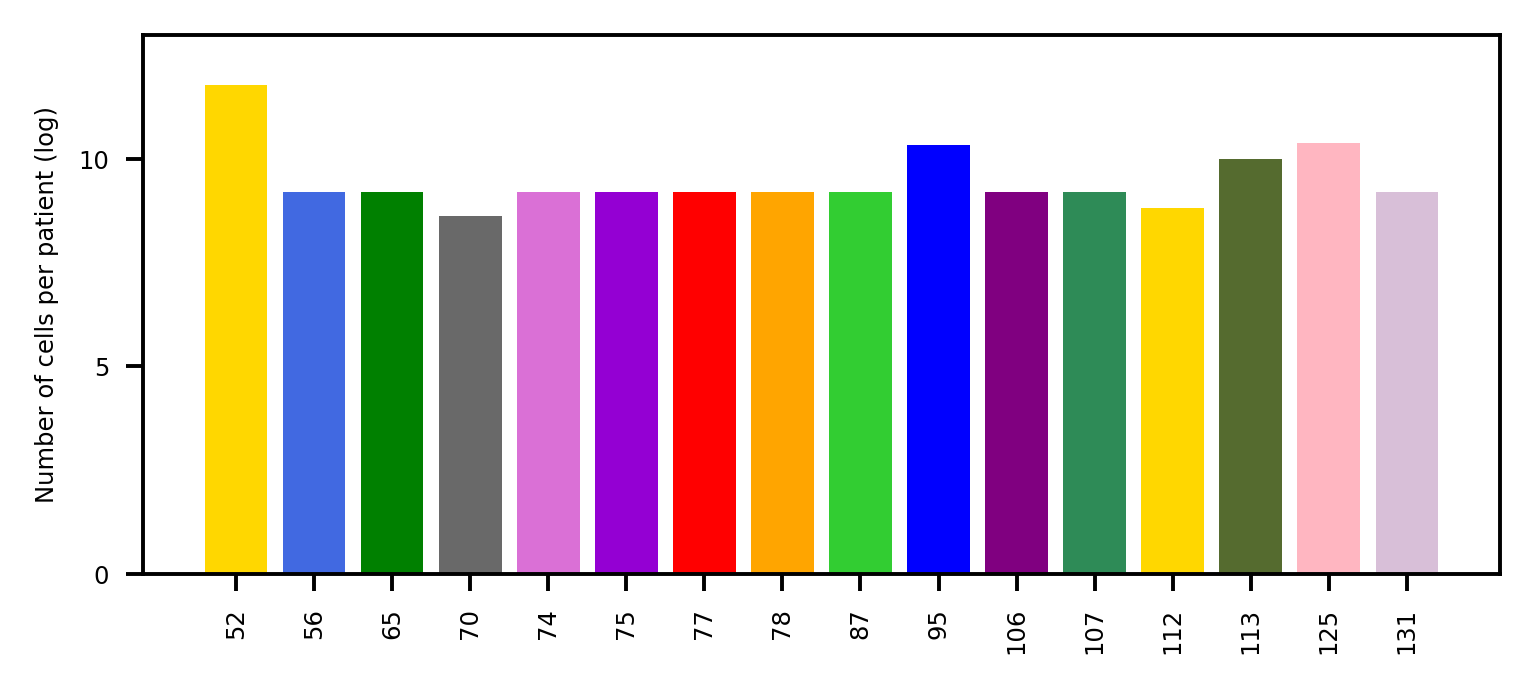

In [22]:
## plot the sizes
N= len(unique_ts)
ind = np.arange(N)
plt.figure(figsize=(5,2), dpi=350)
x=np.arange(N) #[0,1,2,3,4]

y=np.log(counts_ts)#/tot_cells)

for h in range(N):
    plt.bar(x[h], y[h], color=colours_30[h+1])
    
plt.xticks(ind, np.int64(unique_ts),rotation = 90,fontsize=5)
plt.yticks(fontsize=5)
plt.ylabel('Number of cells per patient (log)',fontsize=5)
plt.ylim(0,13)